# Analyze Prediction Results

Given a timestamp, this notebook searches under `output/` for the matching `results.json`, loads the corresponding prediction CSV for one sample size, and draws a regression scatter plot with marginal histograms.

In [30]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
from matplotlib import gridspec
import numpy as np
import pandas as pd

OUTPUT_ROOT = Path('output')
SAMPLE_SIZE = 78891  # set to e.g. 2000, 50000, 78891
USE_MASK_ONLY = True
POINT_SIZE = 8
POINT_ALPHA = 0.2

In [31]:
TIMESTAMP = '2026-04-20-15-39-51'
PREDICTION_TASK = None  # e.g. 'atac_to_5hmc', '5mc_to_5hmc', 'atac_to_5mc'


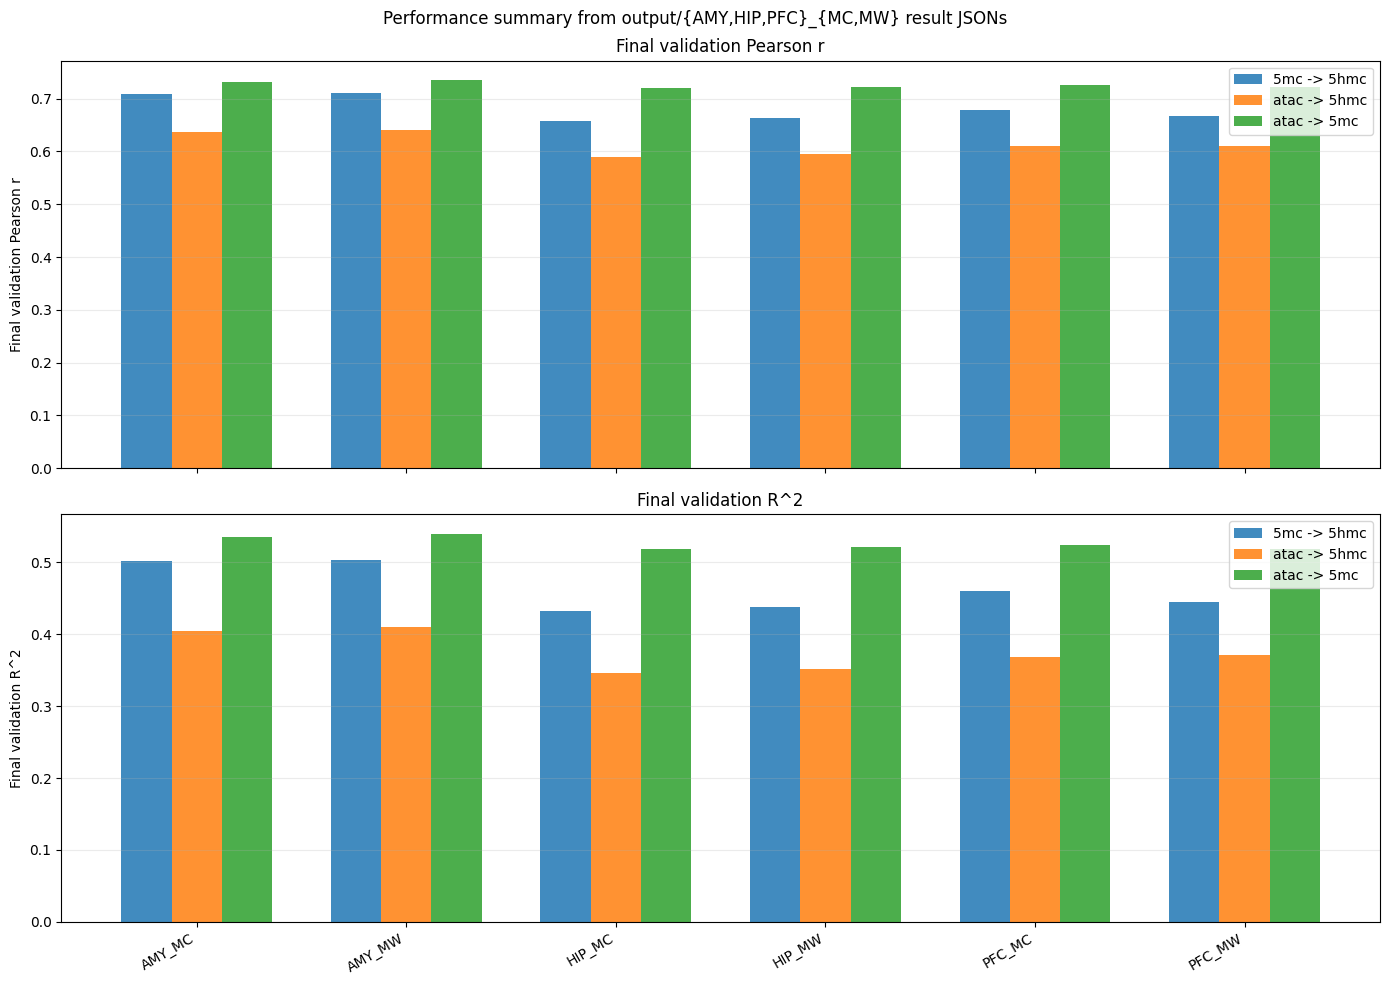

In [ ]:
# Collect result JSONs from output/AMY_MC, AMY_MW, HIP_MC, HIP_MW, PFC_MC, PFC_MW and summarize performance
summary_dirs = [f'{region}_{condition}' for region in ['AMY', 'HIP', 'PFC'] for condition in ['MC', 'MW']]
summary_json_paths = []
for folder_name in summary_dirs:
    summary_json_paths.extend(sorted(OUTPUT_ROOT.glob(f'{folder_name}/*results.json')))

if not summary_json_paths:
    raise FileNotFoundError('No result JSON files found under output/{AMY,HIP,PFC}_{MC,MW}/')

summary_rows = []
for json_path in summary_json_paths:
    with json_path.open('r', encoding='utf-8') as handle:
        bundle = json.load(handle)
    args_block = bundle.get('args', {})
    for result in bundle.get('results', []):
        parent_name = json_path.parent.name
        region, condition = parent_name.split('_', 1)
        input_modality = result.get('input_modality', args_block.get('input_modality'))
        target_modality = result.get('target_modality', args_block.get('target_modality'))
        prediction_task = f'{input_modality} -> {target_modality}'
        summary_rows.append({
            'folder': parent_name,
            'region': region,
            'condition': condition,
            'json_path': str(json_path),
            'timestamp': args_block.get('timestamp'),
            'prediction_task': prediction_task,
            'num_dmrs': result.get('num_dmrs'),
            'best_val_loss': result.get('best_val_loss'),
            'best_val_r2': result.get('best_val_r2'),
            'best_val_pearsonr': result.get('best_val_pearsonr'),
            'final_val_loss': result.get('final_val_loss'),
            'final_val_r2': result.get('final_val_r2'),
            'final_val_pearsonr': result.get('final_val_pearsonr'),
        })

performance_df = pd.DataFrame(summary_rows)
performance_df = performance_df.sort_values(['timestamp'], ascending=[False])
performance_df = performance_df[performance_df['prediction_task'] != 'None -> None']
performance_df = performance_df.drop_duplicates(
    subset=['prediction_task', 'region', 'condition', 'num_dmrs'],
    keep='first',
).copy()


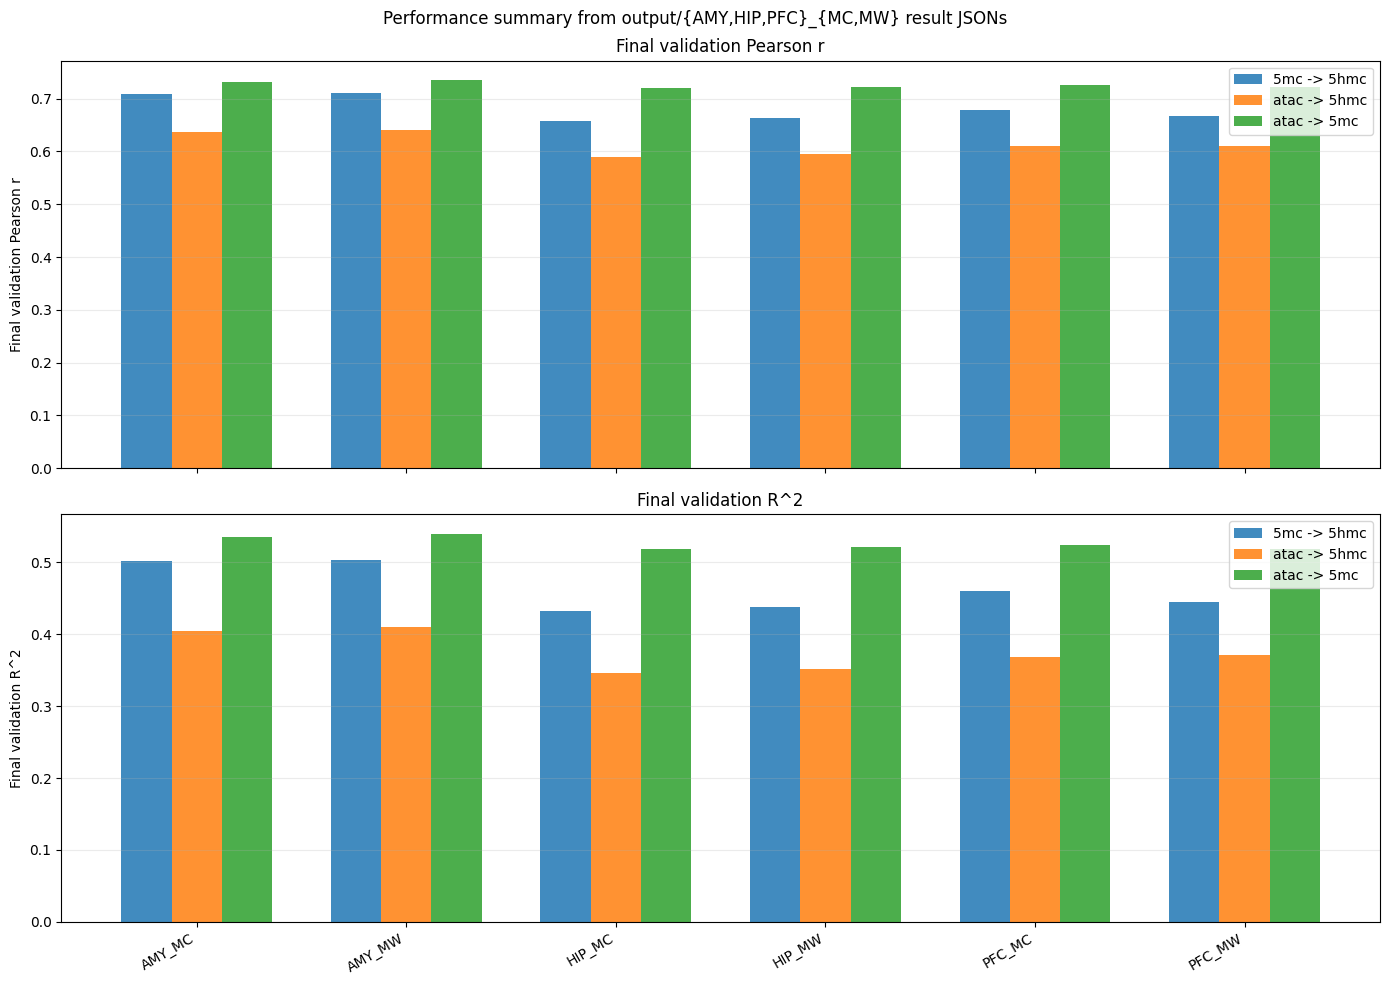

In [33]:
performance_df = performance_df[performance_df['num_dmrs'] == 78891]
performance_df.head(20)

# Plot grouped performance bars across region/condition folders
plot_df = performance_df.copy()
plot_df = plot_df.sort_values(['prediction_task', 'region', 'condition', 'num_dmrs', 'timestamp'])
plot_df = plot_df.groupby(['region', 'condition', 'prediction_task'], as_index=False).tail(1).reset_index(drop=True)

if plot_df.empty:
    raise ValueError('No performance rows available for plotting.')

plot_df['group_label'] = plot_df['region'] + '_' + plot_df['condition']
task_order = sorted(plot_df['prediction_task'].unique())
group_order = [f'{region}_{condition}' for region in ['AMY', 'HIP', 'PFC'] for condition in ['MC', 'MW']]
bar_width = 0.24
x = np.arange(len(group_order))

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
metric_specs = [
    ('final_val_pearsonr', 'Final validation Pearson r', axes[0]),
    ('final_val_r2', 'Final validation R^2', axes[1]),
]

for metric_name, metric_label, axis in metric_specs:
    for task_idx, task_name in enumerate(task_order):
        task_subset = plot_df.loc[plot_df['prediction_task'] == task_name].set_index('group_label')
        values = [task_subset.at[group_name, metric_name] if group_name in task_subset.index else np.nan for group_name in group_order]
        offset = (task_idx - (len(task_order) - 1) / 2) * bar_width
        axis.bar(x + offset, values, width=bar_width, label=task_name, alpha=0.85)
    axis.set_ylabel(metric_label)
    axis.set_title(metric_label)
    axis.grid(axis='y', alpha=0.25)
    axis.legend()

axes[1].set_xticks(x)
axes[1].set_xticklabels(group_order, rotation=30, ha='right')
fig.suptitle('Performance summary from output/{AMY,HIP,PFC}_{MC,MW} result JSONs')
fig.tight_layout()
plt.show()

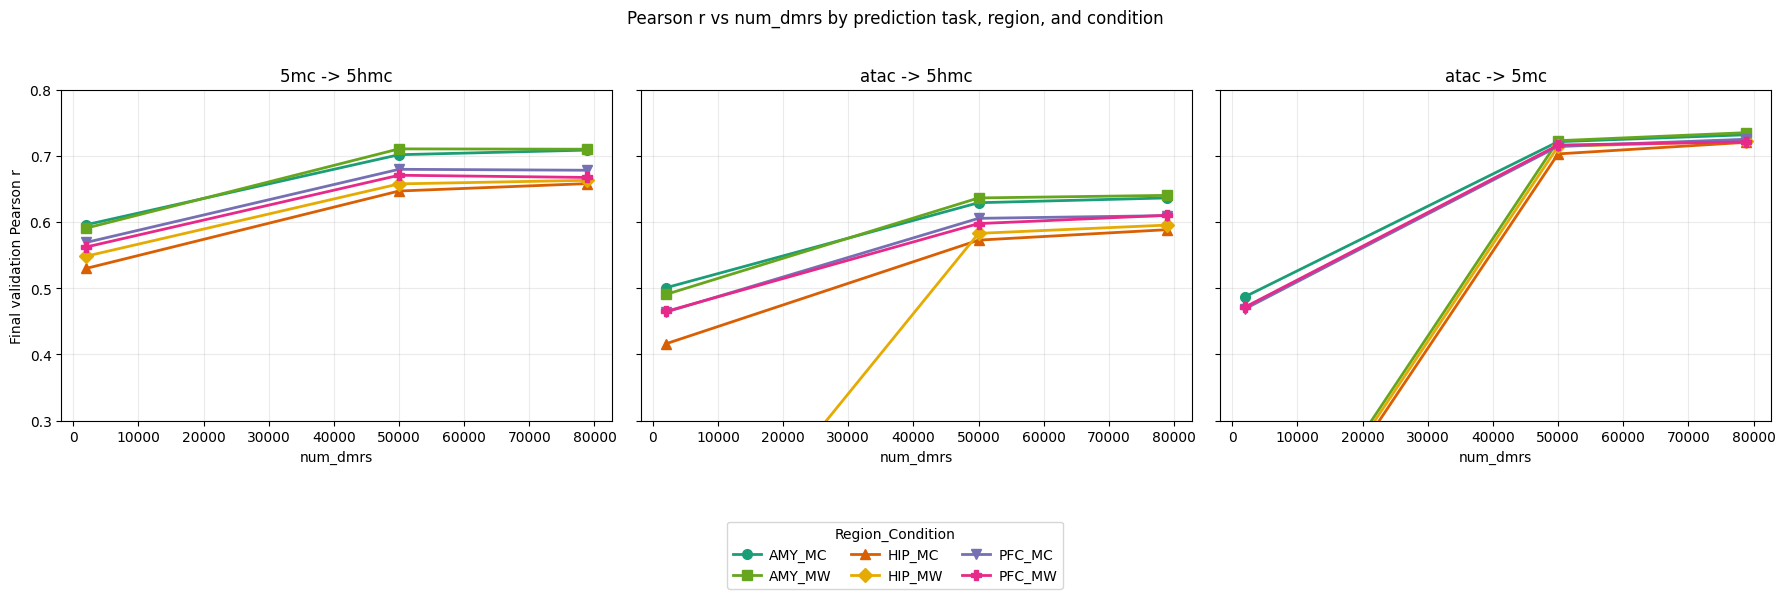

In [48]:
# Plot Pearson r versus num_dmrs for each prediction task, split by region and condition
line_df = pd.DataFrame(summary_rows).copy()
line_df = line_df[line_df['prediction_task'] != 'None -> None'].copy()
line_df = line_df.sort_values(['timestamp'], ascending=[False])
line_df = line_df.drop_duplicates(
    subset=['prediction_task', 'region', 'condition', 'num_dmrs'],
    keep='first',
).copy()

if line_df.empty:
    raise ValueError('No rows available for Pearson r line plot.')

task_order = sorted(line_df['prediction_task'].dropna().unique())
style_order = [(region, condition) for region in ['AMY', 'HIP', 'PFC'] for condition in ['MC', 'MW']]
style_colors = {
    ('AMY', 'MC'): '#1b9e77',
    ('AMY', 'MW'): '#66a61e',
    ('HIP', 'MC'): '#d95f02',
    ('HIP', 'MW'): '#e6ab02',
    ('PFC', 'MC'): '#7570b3',
    ('PFC', 'MW'): '#e7298a',
}
style_markers = {
    ('AMY', 'MC'): 'o',
    ('AMY', 'MW'): 's',
    ('HIP', 'MC'): '^',
    ('HIP', 'MW'): 'D',
    ('PFC', 'MC'): 'v',
    ('PFC', 'MW'): 'P',
}

fig, axes = plt.subplots(1, len(task_order), figsize=(6 * len(task_order), 5), sharey=True)
if len(task_order) == 1:
    axes = [axes]

for axis, task_name in zip(axes, task_order):
    task_df = line_df[line_df['prediction_task'] == task_name].copy()
    for region, condition in style_order:
        subset = task_df[(task_df['region'] == region) & (task_df['condition'] == condition)].copy()
        if subset.empty:
            continue
        subset = subset.sort_values('num_dmrs')
        axis.plot(
            subset['num_dmrs'],
            subset['final_val_pearsonr'],
            marker=style_markers[(region, condition)],
            color=style_colors[(region, condition)],
            linewidth=2.0,
            markersize=7,
            label=f'{region}_{condition}',
        )
    axis.set_title(task_name)
    axis.set_xlabel('num_dmrs')
    axis.set_ylim(0.3, 0.8)
    axis.grid(alpha=0.25)

axes[0].set_ylabel('Final validation Pearson r')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.005),
    ncol=3,
    frameon=True,
    borderaxespad=0.0,
    columnspacing=1.4,
    handletextpad=0.6,
    fancybox=True,
    shadow=False,
    fontsize=10,
    title='Region_Condition',
)
fig.suptitle('Pearson r vs num_dmrs by prediction task, region, and condition', y=1.02)
fig.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

In [2]:
def find_result_jsons(timestamp: str, output_root: Path = OUTPUT_ROOT):
    matches = sorted(output_root.rglob(f'*{timestamp}*results.json'))
    if not matches:
        matches = sorted(output_root.rglob(f'*{timestamp}*.json'))
    return matches


def infer_prediction_task(result_json_path: Path, payload: dict | None = None):
    if payload is not None and 'args' in payload:
        args = payload['args']
        input_modality = args.get('input_modality')
        target_modality = args.get('target_modality')
        if input_modality and target_modality:
            return f'{input_modality}_to_{target_modality}'
    stem = result_json_path.stem
    for task in ['atac_to_5hmc', '5mc_to_5hmc', 'atac_to_5mc']:
        if task in stem:
            return task
    return None


def load_result_bundle(result_json_path: Path):
    with result_json_path.open('r', encoding='utf-8') as handle:
        payload = json.load(handle)
    results_df = pd.DataFrame(payload['results'])
    return payload, results_df


def choose_result_json(matches, prediction_task=None):
    if prediction_task is None:
        return matches[0]
    annotated = []
    for path in matches:
        payload, _ = load_result_bundle(path)
        task = infer_prediction_task(path, payload)
        annotated.append((path, task))
    filtered = [path for path, task in annotated if task == prediction_task]
    if not filtered:
        available = sorted({task for _, task in annotated if task is not None})
        raise ValueError(f'No result JSON matched prediction task {prediction_task}. Available: {available}')
    if len(filtered) > 1:
        raise ValueError(f'More than one result JSON matched prediction task {prediction_task}: {[str(path) for path in filtered]}')
    return filtered[0]


def choose_sample_row(results_df: pd.DataFrame, sample_size=None):
    if sample_size is None:
        return results_df.sort_values('num_dmrs').iloc[-1]
    matched = results_df.loc[results_df['num_dmrs'] == sample_size]
    if matched.empty:
        raise ValueError(f'Sample size {sample_size} not found. Available: {sorted(results_df["num_dmrs"].tolist())}')
    return matched.iloc[0]


def load_signal_csv(signal_csv_path: str | Path):
    path = Path(signal_csv_path)
    if not path.is_absolute():
        path = Path.cwd() / path
    if not path.exists():
        raise FileNotFoundError(path)
    frame = pd.read_csv(path)
    if 'predicted_signal' in frame.columns:
        frame['predicted_signal_clipped'] = frame['predicted_signal'].clip(0, 100)
    return frame, path


def get_prediction_column(frame: pd.DataFrame):
    return 'predicted_signal_clipped' if 'predicted_signal_clipped' in frame.columns else 'predicted_signal'


def compute_metrics(frame: pd.DataFrame):
    pred_col = get_prediction_column(frame)
    true_values = frame['true_signal'].to_numpy(dtype=float)
    pred_values = frame[pred_col].to_numpy(dtype=float)
    mse = np.mean((pred_values - true_values) ** 2)
    rmse = float(np.sqrt(mse))
    mae = float(np.mean(np.abs(pred_values - true_values)))
    corr = float(np.corrcoef(true_values, pred_values)[0, 1]) if len(frame) > 1 else np.nan
    ss_res = np.sum((pred_values - true_values) ** 2)
    ss_tot = np.sum((true_values - true_values.mean()) ** 2)
    r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan
    return {'rmse': rmse, 'mae': mae, 'pearson_r': corr, 'r2': r2, 'n_points': int(len(frame))}


def smooth_hist2d(hist2d: np.ndarray, passes: int = 2):
    kernel = np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]], dtype=float)
    kernel /= kernel.sum()
    smoothed = hist2d.astype(float).copy()
    for _ in range(passes):
        padded = np.pad(smoothed, 1, mode='edge')
        updated = np.zeros_like(smoothed)
        for row in range(smoothed.shape[0]):
            for col in range(smoothed.shape[1]):
                window = padded[row:row + 3, col:col + 3]
                updated[row, col] = np.sum(window * kernel)
        smoothed = updated
    return smoothed


def plot_joint_regression(frame: pd.DataFrame, title: str, bins: int = 60, top_count_ylim: int | None = 50000):
    pred_col = get_prediction_column(frame)
    true_values = frame['true_signal'].to_numpy(dtype=float)
    pred_values = frame[pred_col].to_numpy(dtype=float)

    metrics = compute_metrics(frame)

    min_value = float(min(true_values.min(), pred_values.min()))
    max_value = float(max(true_values.max(), pred_values.max()))
    padding = max((max_value - min_value) * 0.03, 1e-6)
    xlim = (min_value - padding, max_value + padding)

    fig = plt.figure(figsize=(8, 8))
    grid = gridspec.GridSpec(4, 4, figure=fig, hspace=0.05, wspace=0.05)
    ax_joint = fig.add_subplot(grid[1:4, 0:3])
    ax_top = fig.add_subplot(grid[0, 0:3], sharex=ax_joint)
    ax_right = fig.add_subplot(grid[1:4, 3], sharey=ax_joint)

    density_bins = max(120, bins * 2)
    hist2d, xedges, yedges = np.histogram2d(true_values, pred_values, bins=density_bins, range=[xlim, xlim])
    hist2d = smooth_hist2d(hist2d, passes=2)
    xcenters = 0.5 * (xedges[:-1] + xedges[1:])
    ycenters = 0.5 * (yedges[:-1] + yedges[1:])

    positive_density = hist2d[hist2d > 0]
    if positive_density.size > 10:
        level_values = np.percentile(positive_density, [60, 75, 85, 92, 97])
        level_values = np.unique(level_values)
        if level_values.size >= 2:
            fill_colors = ['#e8f5e9', '#c8e6c9', '#a5d6a7', '#81c784', '#66bb6a'][:level_values.size]
            filled = ax_joint.contourf(
                xcenters,
                ycenters,
                hist2d.T,
                levels=level_values,
                colors=fill_colors,
                alpha=0.22,
                antialiased=True,
            )
            for collection in filled.collections:
                collection.set_edgecolor('face')
            ax_joint.contour(
                xcenters,
                ycenters,
                hist2d.T,
                levels=level_values,
                colors='#1b5e20',
                linewidths=1.15,
                alpha=0.95,
            )

    ax_joint.scatter(
        true_values,
        pred_values,
        s=POINT_SIZE,
        alpha=POINT_ALPHA,
        edgecolors='none',
        color='#a5d6a7',
    )
    ax_joint.plot(xlim, xlim, linestyle='--', linewidth=1.0, color='black')

    if len(frame) > 1:
        slope, intercept = np.polyfit(true_values, pred_values, 1)
        fit_x = np.linspace(xlim[0], xlim[1], 200)
        ax_joint.plot(fit_x, slope * fit_x + intercept, color='tab:red', linewidth=1.2)

    stats_text = f"Pearson r = {metrics['pearson_r']:.4f}\nR^2 = {metrics['r2']:.4f}"
    ax_joint.text(
        0.03,
        0.97,
        stats_text,
        transform=ax_joint.transAxes,
        va='top',
        ha='left',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='0.7'),
    )

    ax_top.hist(true_values, bins=bins, color='tab:blue', alpha=0.75)
    ax_right.hist(pred_values, bins=bins, orientation='horizontal', color='tab:orange', alpha=0.75)

    ax_joint.set_xlim(xlim)
    ax_joint.set_ylim(xlim)
    ax_joint.set_xlabel('Ground truth')
    ax_joint.set_ylabel('Prediction (clipped to 0-100)')
    ax_joint.set_title(title)
    ax_top.set_ylabel('Count')
    ax_right.set_xlabel('Count')

    if top_count_ylim is not None:
        ax_top.set_ylim(0, top_count_ylim)

    plt.setp(ax_top.get_xticklabels(), visible=False)
    plt.setp(ax_right.get_yticklabels(), visible=False)
    ax_top.tick_params(axis='x', which='both', bottom=False)
    ax_right.tick_params(axis='y', which='both', left=False)

    return fig

In [3]:
matches = find_result_jsons(TIMESTAMP)
if not matches:
    raise FileNotFoundError(f'No result JSON found for timestamp: {TIMESTAMP}')

result_json_path = choose_result_json(matches, prediction_task=PREDICTION_TASK)
payload, results_df = load_result_bundle(result_json_path)
selected_row = choose_sample_row(results_df, SAMPLE_SIZE)
signal_df, signal_path = load_signal_csv(selected_row['signal_csv'])

analysis_df = signal_df.copy()
if USE_MASK_ONLY and 'mask' in analysis_df.columns:
    analysis_df = analysis_df.loc[analysis_df['mask'].astype(float) > 0].copy()

metrics = compute_metrics(analysis_df)

print('Matched result JSON files:', [str(path) for path in matches])
print('Selected prediction task:', PREDICTION_TASK)
print('Result JSON:', result_json_path)
print('Signal CSV :', signal_path)
print('Available sample sizes:', results_df['num_dmrs'].tolist())
print('Selected row:')
display(pd.DataFrame([selected_row]))
print('Metrics:')
display(pd.DataFrame([metrics]))

/tmp/ipykernel_1814450/2633421001.py:61: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  frame = pd.read_csv(path)


Matched result JSON files: ['output/AMY_MC/2026-04-20-15-39-51_atac_to_5mc_results.json']
Selected prediction task: None
Result JSON: output/AMY_MC/2026-04-20-15-39-51_atac_to_5mc_results.json
Signal CSV : /home/junyichen/code/mmllm/output/AMY_MC/2026-04-20-15-39-51_atac_to_5mc_78891.csv
Available sample sizes: [2000, 50000, 78891]
Selected row:


,num_dmrs,input_modality,context_modalities,target_modality,mask_mode,train_regions,val_regions,non_overlap_groups,best_epoch,final_lr,best_val_loss,best_val_r2,best_val_pearsonr,final_val_loss,final_val_r2,final_val_pearsonr,signal_csv,regression_plot
2,78891,atac,sequence,5mc,cpg_both,64687,14204,56162,30,0.00073,439.573066,0.535013,0.731867,439.573066,0.535013,0.731867,output/AMY_MC/2026-04-20-15-39-51_atac_to_5mc_...,output/AMY_MC/2026-04-20-15-39-51_atac_to_5mc_...


Metrics:


,rmse,mae,pearson_r,r2,n_points
0,21.145299,16.154223,0.731969,0.535239,498652


In [4]:

metrics = compute_metrics(analysis_df)

print('Result JSON:', result_json_path)
print('Signal CSV :', signal_path)
print('Available sample sizes:', results_df['num_dmrs'].tolist())
print('Selected row:')
display(pd.DataFrame([selected_row]))
print('Metrics:')
display(pd.DataFrame([metrics]))

Result JSON: output/AMY_MC/2026-04-20-15-39-51_atac_to_5mc_results.json
Signal CSV : /home/junyichen/code/mmllm/output/AMY_MC/2026-04-20-15-39-51_atac_to_5mc_78891.csv
Available sample sizes: [2000, 50000, 78891]
Selected row:


,num_dmrs,input_modality,context_modalities,target_modality,mask_mode,train_regions,val_regions,non_overlap_groups,best_epoch,final_lr,best_val_loss,best_val_r2,best_val_pearsonr,final_val_loss,final_val_r2,final_val_pearsonr,signal_csv,regression_plot
2,78891,atac,sequence,5mc,cpg_both,64687,14204,56162,30,0.00073,439.573066,0.535013,0.731867,439.573066,0.535013,0.731867,output/AMY_MC/2026-04-20-15-39-51_atac_to_5mc_...,output/AMY_MC/2026-04-20-15-39-51_atac_to_5mc_...


Metrics:


,rmse,mae,pearson_r,r2,n_points
0,21.145299,16.154223,0.731969,0.535239,498652


/tmp/ipykernel_1814450/2633421001.py:139: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for collection in filled.collections:


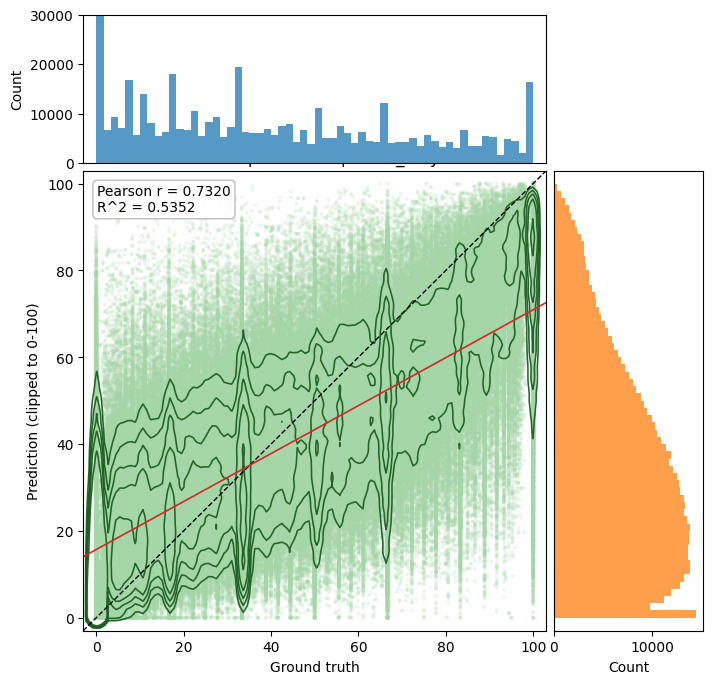

In [5]:
title = f"{selected_row['input_modality']} -> {selected_row['target_modality']} | n={int(selected_row['num_dmrs'])} | mask_only={USE_MASK_ONLY}"
fig = plot_joint_regression(analysis_df, title=title,top_count_ylim=30000)
plt.show()

In [6]:
preview_columns = ['true_signal', 'predicted_signal']
if 'predicted_signal_clipped' in analysis_df.columns:
    preview_columns.append('predicted_signal_clipped')
preview_columns.extend(['mask', 'base', 'chr', 'genomic_position'])
analysis_df[preview_columns].head(20)

,true_signal,predicted_signal,predicted_signal_clipped,mask,base,chr,genomic_position
5,83.333336,25.127995,25.127995,1.0,C,4,36611047
6,0.000000,2.644269,2.644269,1.0,G,4,36611048
96,46.666668,48.001038,48.001038,1.0,C,4,36611138
97,12.121212,20.059738,20.059738,1.0,G,4,36611139
166,58.888893,57.645203,57.645203,1.0,C,4,36611208
167,0.000000,19.385609,19.385609,1.0,G,4,36611209
211,52.380955,80.760117,80.760117,1.0,C,4,36611253
212,16.666668,49.002701,49.002701,1.0,G,4,36611254
219,80.000000,50.179295,50.179295,1.0,C,4,36611261
220,91.071426,86.933762,86.933762,1.0,G,4,36611262


,rmse,mae,pearson_r,r2,n_points
0,21.315755,16.327675,0.726479,0.527245,249326


/tmp/ipykernel_1814450/2633421001.py:139: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for collection in filled.collections:


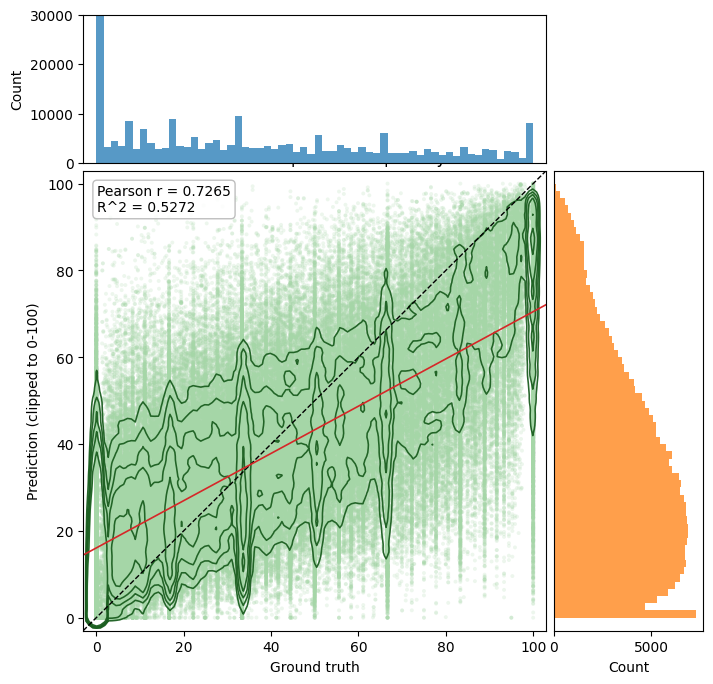

In [7]:
c_only_df = analysis_df.loc[analysis_df['base'].astype(str).str.upper() == 'C'].copy()
if c_only_df.empty:
    raise ValueError('No C-base rows found in the current analysis_df.')

c_metrics = compute_metrics(c_only_df)
display(pd.DataFrame([c_metrics]))

c_title = f"{selected_row['input_modality']} -> {selected_row['target_modality']} | n={int(selected_row['num_dmrs'])} | C only"
fig = plot_joint_regression(c_only_df, title=c_title, top_count_ylim=30000)
plt.show()

,rmse,mae,pearson_r,r2,n_points
0,20.973458,15.980771,0.737413,0.543216,249326


/tmp/ipykernel_1814450/2633421001.py:139: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for collection in filled.collections:


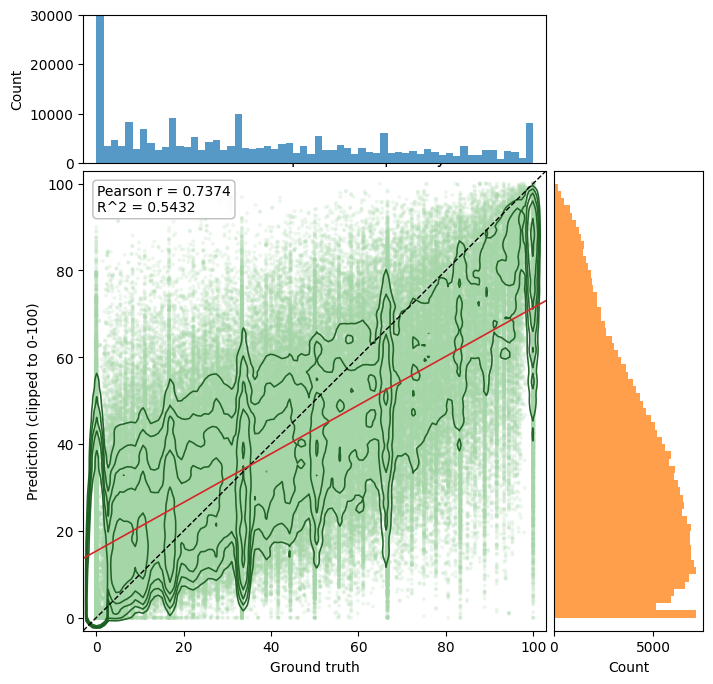

In [8]:
c_only_df = analysis_df.loc[analysis_df['base'].astype(str).str.upper() == 'G'].copy()
if c_only_df.empty:
    raise ValueError('No C-base rows found in the current analysis_df.')

c_metrics = compute_metrics(c_only_df)
display(pd.DataFrame([c_metrics]))

c_title = f"{selected_row['input_modality']} -> {selected_row['target_modality']} | n={int(selected_row['num_dmrs'])} | C only"
fig = plot_joint_regression(c_only_df, title=c_title, top_count_ylim=30000)
plt.show()